**Actividad práctica - Módulo 1**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [ ]:
# Cargamos el dataset (Ejemplo cuba 7076 - ultimos 3 meses)
df = pd.read_csv('Practica C7076.csv', sep=';')

In [ ]:
# Primer vistazo
df.head()

,FT_TURNO,TU_SEMI_TURNO,N_FECHA_SMTU,CUBA,POTSTATE,AGEBSQ,POTAGE,ALF3,ALF3C,ALF3D,...,V_ULT_V,V_ULT_TI,V_ULT_GA,SMRWFC,MI_EA,ENERGIA_EA,MI_BLOCK_A1,MI_BLOCK_A2,MI_BLOCK_A3,MI_BLOCK_A4
0,13/4/2026 00:00,1,2026041311,7076,3,3848,3848,NaN,"12,1","11,8",...,52,34,119,"0,0577",0,0,0,0,0,0
1,13/4/2026 00:00,2,2026041312,7076,3,"3848,1667","3848,1667",NaN,"12,1","11,8",...,52,34,118,0,0,0,0,0,0,0
2,13/4/2026 00:00,3,2026041323,7076,3,"3848,3333","3848,3333",NaN,"12,1","11,8",...,53,34,119,0,0,0,0,0,0,0
3,13/4/2026 00:00,4,2026041324,7076,3,"3848,5","3848,5",NaN,"12,1","11,8",...,53,34,119,0,0,0,0,0,0,0
4,13/4/2026 00:00,5,2026041335,7076,3,"3848,6667","3848,6667","10,9","12,1","10,9",...,53,34,119,0,0,0,0,0,0,0


In [ ]:
# ¿Cuántas filas y columnas? ¿Qué tipos de datos?
print("Dimensiones:", df.shape)
df.info()

Dimensiones: (729, 179)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Columns: 179 entries, FT_TURNO to MI_BLOCK_A4
dtypes: float64(60), int64(79), object(40)
memory usage: 1019.6+ KB


In [ ]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,TU_SEMI_TURNO,N_FECHA_SMTU,CUBA,POTSTATE,AMALF3,AMBB,AMCAF2,AMCRY,AMNA2CO3,CNMVTC,...,K_AGR_METAL_PUENTE,N_PUENTE_METAL,V_ULT_V,V_ULT_TI,V_ULT_GA,ENERGIA_EA,MI_BLOCK_A1,MI_BLOCK_A2,MI_BLOCK_A3,MI_BLOCK_A4
count,729.000000,7.290000e+02,729.0,729.0,2.000000,0.0,0.0,1.0,0.0,729.000000,...,0.0,90.000000,729.000000,729.000000,729.000000,729.000000,729.0,729.0,729.0,729.0
mean,3.493827,2.026061e+09,7076.0,3.0,30.000000,NaN,NaN,150.0,NaN,10.080933,...,NaN,6.100000,48.582990,37.038409,120.875171,0.264746,0.0,0.0,0.0,0.0
std,1.708987,1.187341e+04,0.0,0.0,21.213203,NaN,NaN,NaN,NaN,7.074391,...,NaN,3.119529,3.318949,2.499155,8.525949,3.221644,0.0,0.0,0.0,0.0
min,1.000000,2.026041e+09,7076.0,3.0,15.000000,NaN,NaN,150.0,NaN,0.000000,...,NaN,1.000000,40.000000,32.000000,104.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,2.026051e+09,7076.0,3.0,22.500000,NaN,NaN,150.0,NaN,5.000000,...,NaN,3.000000,46.000000,36.000000,115.000000,0.000000,0.0,0.0,0.0,0.0
50%,3.000000,2.026061e+09,7076.0,3.0,30.000000,NaN,NaN,150.0,NaN,9.000000,...,NaN,7.000000,49.000000,37.000000,121.000000,0.000000,0.0,0.0,0.0,0.0
75%,5.000000,2.026071e+09,7076.0,3.0,37.500000,NaN,NaN,150.0,NaN,13.000000,...,NaN,8.000000,51.000000,38.000000,127.000000,0.000000,0.0,0.0,0.0,0.0
max,6.000000,2.026081e+09,7076.0,3.0,45.000000,NaN,NaN,150.0,NaN,48.000000,...,NaN,12.000000,56.000000,69.000000,144.000000,53.000000,0.0,0.0,0.0,0.0


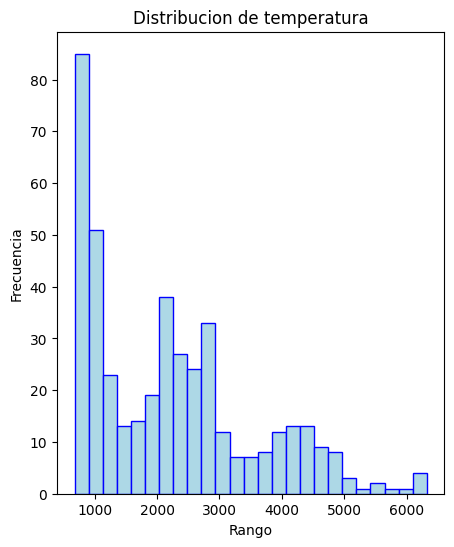

In [ ]:
plt.figure(figsize=(5, 6))
plt.hist(df["TFE"], bins=25, color="lightblue", edgecolor="blue")
plt.title("Distribucion de temperatura")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.show()

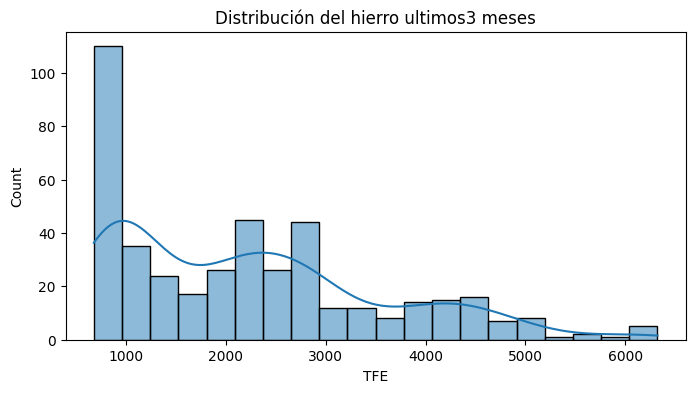

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="TFE", bins=20, kde=True)  # kde=True agrega la curva de densidad
plt.title("Distribución del hierro ultimos3 meses")
plt.show()

In [ ]:
# 1. Convertir 'FT_TURNO' a formato de fecha y hora
df['FT_TURNO'] = pd.to_datetime(df['FT_TURNO'], format='%d/%m/%Y %H:%M')

# 2. Encontrar la fecha máxima en el DataFrame
fecha_maxima = df['FT_TURNO'].max()

# 3. Calcular la fecha de inicio de la última semana
fecha_inicio_ultima_semana = fecha_maxima - pd.Timedelta(days=7)

# 4. Filtrar el DataFrame para la última semana
df_ultima_semana = df[df['FT_TURNO'] >= fecha_inicio_ultima_semana]

print(f"Fechas en el DataFrame filtrado (última semana): {df_ultima_semana['FT_TURNO'].min().strftime('%Y-%m-%d')} a {df_ultima_semana['FT_TURNO'].max().strftime('%Y-%m-%d')}")

Fechas en el DataFrame filtrado (última semana): 2026-08-05 a 2026-08-12


Ahora, graficamos la distribución de `TFE` para los datos de la última semana:

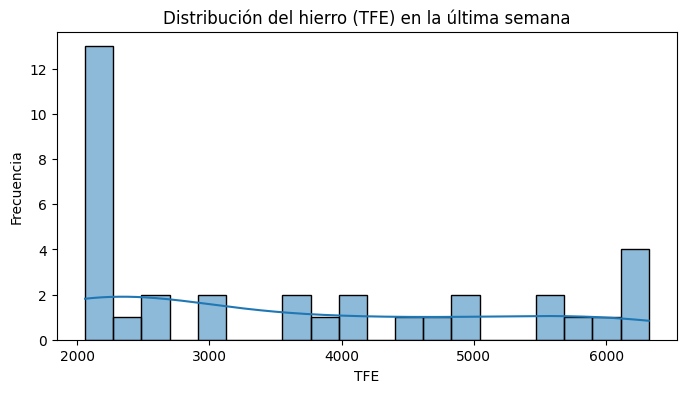

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df_ultima_semana, x="TFE", bins=20, kde=True)
plt.title("Distribución del hierro (TFE) en la última semana")
plt.xlabel("TFE")
plt.ylabel("Frecuencia")
plt.show()

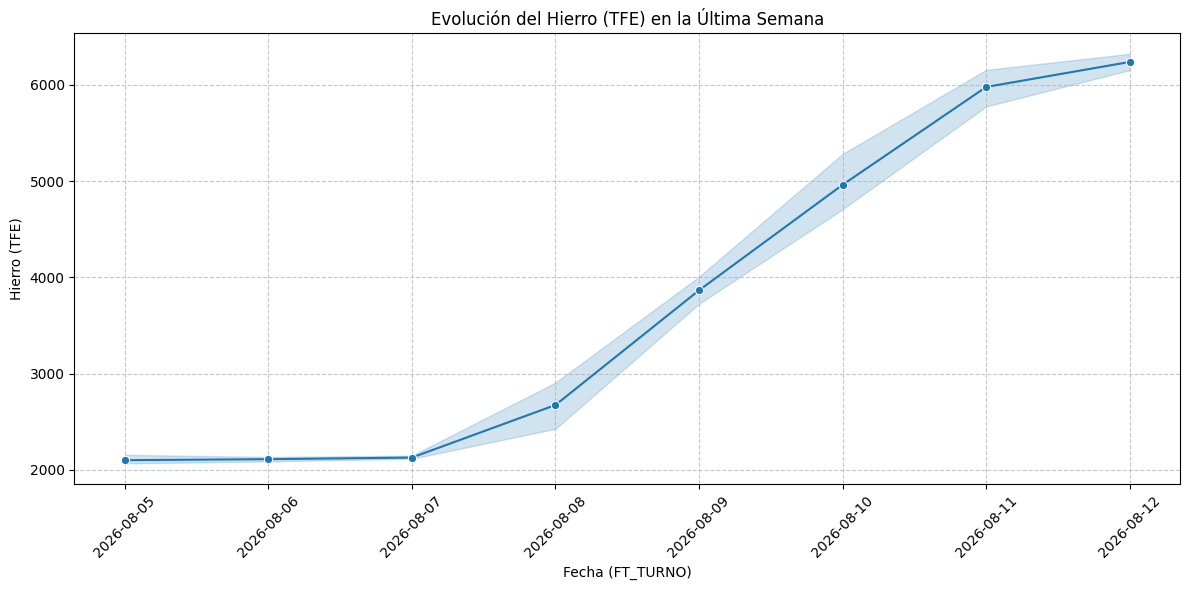

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_ultima_semana, x='FT_TURNO', y='TFE', marker='o')
plt.title('Evolución del Hierro (TFE) en la Última Semana')
plt.xlabel('Fecha (FT_TURNO)')
plt.ylabel('Hierro (TFE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotar las etiquetas del eje X para mejor lectura
plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

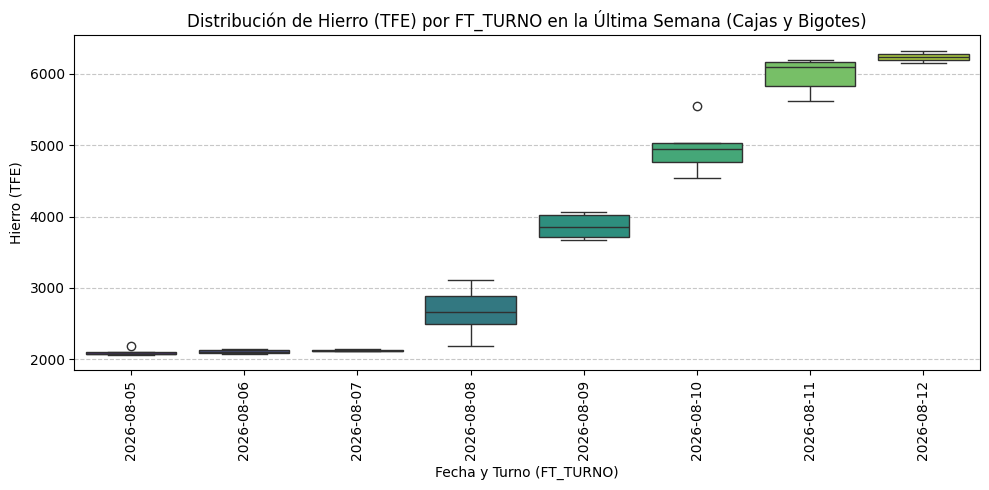

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_ultima_semana, x='FT_TURNO', y='TFE', hue='FT_TURNO', palette='viridis', legend=False)
plt.title('Distribución de Hierro (TFE) por FT_TURNO en la Última Semana (Cajas y Bigotes)')
plt.xlabel('Fecha y Turno (FT_TURNO)')
plt.ylabel('Hierro (TFE)')
plt.xticks(rotation=90) # Rotar las etiquetas del eje X para mejor lectura
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

**Se observa un aumento del hierro de la cuba en la ultima semana, con un aumento en la dispesión de los datos**

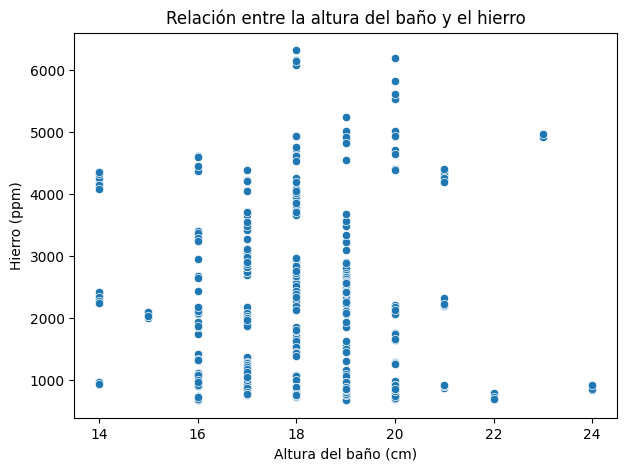

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="HBD", y="TFE")
plt.title("Relación entre la altura del baño y el hierro")
plt.xlabel("Altura del baño (cm)")
plt.ylabel("Hierro (ppm)")
plt.show()

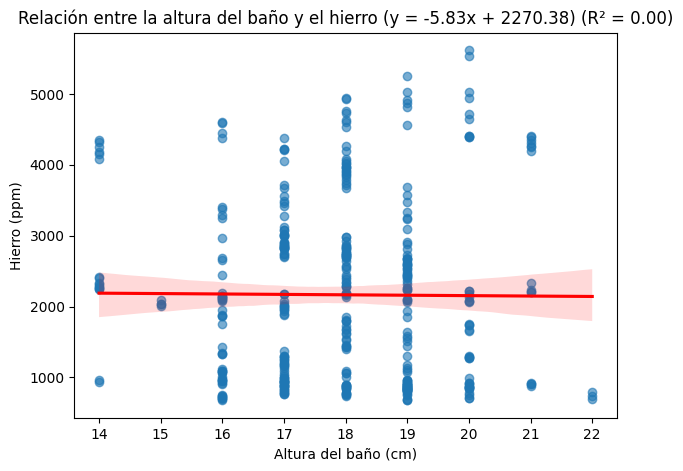

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Crear una copia del DataFrame para trabajar y asegurar que no modificamos el original de forma inesperada
df_plot = df.copy()

# Convertir 'HBD' a numérico, manejando la coma como separador decimal y los errores
df_plot['HBD'] = df_plot['HBD'].astype(str).str.replace(',', '.', regex=False)
df_plot['HBD'] = pd.to_numeric(df_plot['HBD'], errors='coerce')

# Eliminar filas con NaN en 'HBD' o 'TFE' para el cálculo de la regresión
df_reg_calc = df_plot[['HBD', 'TFE']].dropna()

# --- Eliminación de Outliers (valores atípicos) usando IQR ---
# Función para remover outliers basada en IQR
def remove_outliers_iqr(df_in, col_name):
    Q1 = df_in[col_name].quantile(0.25)
    Q3 = df_in[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_in[(df_in[col_name] >= lower_bound) & (df_in[col_name] <= upper_bound)]

# Aplicar la remoción de outliers a 'HBD' y 'TFE'
df_reg_cleaned = remove_outliers_iqr(df_reg_calc, 'HBD')
df_reg_cleaned = remove_outliers_iqr(df_reg_cleaned, 'TFE')

r2_text = ""
equation_text = ""

# Asegurarse de que hay suficientes puntos y variabilidad en X para calcular la regresión después de limpiar outliers
if not df_reg_cleaned.empty and len(df_reg_cleaned['HBD'].unique()) > 1:
    X = df_reg_cleaned[['HBD']]
    y = df_reg_cleaned['TFE']

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    r2_text = f" (R² = {r2:.2f})"

    # Obtener la ecuación de la línea
    intercept = model.intercept_
    slope = model.coef_[0]
    equation_text = f" (y = {slope:.2f}x + {intercept:.2f})"
else:
    r2_text = " (R² no disponible después de limpiar outliers)"
    equation_text = " (Regresión no disponible después de limpiar outliers)"


plt.figure(figsize=(7, 5))
# Usar el DataFrame limpio para el regplot
sns.regplot(data=df_reg_cleaned, x="HBD", y="TFE", scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title(f"Relación entre la altura del baño y el hierro{equation_text}{r2_text}")
plt.xlabel("Altura del baño (cm)")
plt.ylabel("Hierro (ppm)")
plt.show()

**Se observa que no hay correlación del nivel de baño con el contenido de hierro **

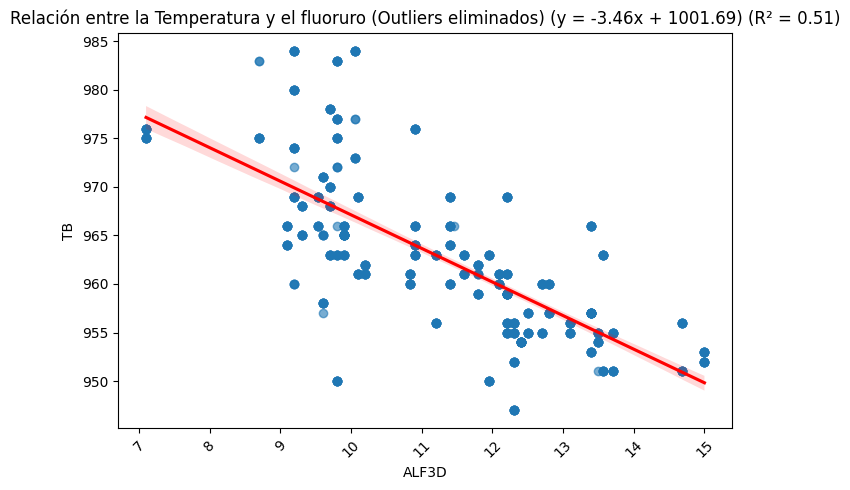

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Crear una copia del DataFrame para trabajar y asegurar que no modificamos el original
df_plot_ax = df.copy()

# Convertir 'ALF3D' a numérico, manejando la coma como separador decimal y los errores
df_plot_ax['ALF3D'] = df_plot_ax['ALF3D'].astype(str).str.replace(',', '.', regex=False)
df_plot_ax['ALF3D'] = pd.to_numeric(df_plot_ax['ALF3D'], errors='coerce')

# Convertir 'TBD' a numérico (asumiendo que podría tener el mismo problema de coma)
df_plot_ax['TBD'] = df_plot_ax['TBD'].astype(str).str.replace(',', '.', regex=False)
df_plot_ax['TBD'] = pd.to_numeric(df_plot_ax['TBD'], errors='coerce')

# Eliminar filas con NaN en 'ALF3D' o 'TBD' para asegurar el orden y el plot correcto
df_plot_ax = df_plot_ax.dropna(subset=['ALF3D', 'TBD'])

# --- Eliminación de Outliers (valores atípicos) usando IQR ---
def remove_outliers_iqr(df_in, col_name):
    Q1 = df_in[col_name].quantile(0.25)
    Q3 = df_in[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_in[(df_in[col_name] >= lower_bound) & (df_in[col_name] <= upper_bound)]

# Aplicar la remoción de outliers a 'ALF3D' y 'TBD'
df_plot_ax_cleaned = remove_outliers_iqr(df_plot_ax, 'ALF3D')
df_plot_ax_cleaned = remove_outliers_iqr(df_plot_ax_cleaned, 'TBD')

# Ordenar el DataFrame por 'ALF3D' para que los puntos se muestren en orden numérico en el eje X
df_plot_ax_cleaned = df_plot_ax_cleaned.sort_values(by='ALF3D')

r2_text = ""
equation_text = ""

# Asegurarse de que hay suficientes puntos y variabilidad en X para calcular la regresión después de limpiar outliers
if not df_plot_ax_cleaned.empty and len(df_plot_ax_cleaned['ALF3D'].unique()) > 1:
    X_reg = df_plot_ax_cleaned[['ALF3D']]
    y_reg = df_plot_ax_cleaned['TBD']

    model_reg = LinearRegression()
    model_reg.fit(X_reg, y_reg)
    y_pred_reg = model_reg.predict(X_reg)

    r2 = r2_score(y_reg, y_pred_reg)
    r2_text = f" (R² = {r2:.2f})"

    # Obtener la ecuación de la línea
    intercept = model_reg.intercept_
    slope = model_reg.coef_[0]
    equation_text = f" (y = {slope:.2f}x + {intercept:.2f})"
else:
    r2_text = " (R² no disponible)"
    equation_text = " (Regresión no disponible)"


plt.figure(figsize=(7, 5))
sns.regplot(data=df_plot_ax_cleaned, x="ALF3D", y="TBD", scatter_kws={'alpha':0.6}, line_kws={'color': 'red'}) # Usar regplot para la regresión
plt.title(f"Relación entre la Temperatura y el fluoruro (Outliers eliminados){equation_text}{r2_text}") # Título actualizado con regresión
plt.xlabel("ALF3D")
plt.ylabel("TB")
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejorar la lectura
plt.tight_layout() # Ajusta el diseño para que no se corten las etiquetas
plt.show()

**Se observa que a mayor contenido de AlF3, la temperatura del baño baja**